<a href="https://colab.research.google.com/github/FabriceSALAVI/agri-dom-597/blob/main/Amartya_SEN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
"""
Transform yearly ITIE-RDC "Revenue" and "Spending" Excel files (2015-2024) into
two clean panel datasets (one row = one firm x one year, keeping sub-detail):

  1. Spending panel  -> panel_spending.xlsx
     One row per (year, sector, firm, beneficiary), with:
       - Secteur classification kept as-is (Pétrolier / Minier / ... as found in file)
       - Groupe_social : a classification of the beneficiary into a social category
         (Santé, Education, Agriculture, Communaute/Developpement, Administration/
         Securite, Religion/Culte, Genre/Droits humains, Environnement/Eau,
         Infrastructure, Sport/Culture, Personnes affectees par le projet (PAP),
         Autre/Non classe)
       - Dépenses sociales obligatoires (En numéraire / En nature)
       - Dépenses sociales volontaires (En numéraire / En nature)
       - Total

  2. Revenue panel -> panel_revenue.xlsx
     One row per (year, sector, phase, firm), with:
       - Secteur (Pétrolier / Forestier / Minier / Artisanat minier)
       - Phase (ENTREPRISE DE L'ETAT / PHASE EXPLOITATION / PHASE EXPLORATION /
         PHASE PRODUCTION / PHASE --)
       - Montants initialement déclarés (Sociétés / Etat / Différence)
       - Ajustements (Sociétés / Etat / Différence)
       - Montants après ajustements (Sociétés / Etat / Différence)

Both outputs also get a long/tidy CSV twin for easy use in stats software
(Stata, R, Python) doing panel-data analysis.
"""

import re
import unicodedata
from pathlib import Path

import openpyxl
import pandas as pd

UPLOAD_DIR = Path("/content/")
OUT_DIR = Path("/content/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

YEARS = list(range(2015, 2025))

# --------------------------------------------------------------------------
# Helpers
# --------------------------------------------------------------------------

def to_number(v):
    """Excel cells here are sometimes numbers, sometimes '-', sometimes None."""
    if v is None:
        return None
    if isinstance(v, (int, float)):
        return v
    s = str(v).strip()
    if s in ("", "-", "--"):
        return None
    s = s.replace("\xa0", "").replace(" ", "").replace(",", "")
    s = s.replace("(", "-").replace(")", "")
    try:
        return float(s)
    except ValueError:
        return None


def strip_accents(s: str) -> str:
    return "".join(
        c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c) != "Mn"
    )


def norm(s: str) -> str:
    return strip_accents(str(s)).lower()


# --------------------------------------------------------------------------
# 1. SPENDING  ("Dépenses sociales par secteur et par entreprise")
# --------------------------------------------------------------------------

# Ordered list of (category_label, [keywords]) - checked in order, first match wins.
# Keywords are matched against the accent-stripped, lower-cased beneficiary text.
SOCIAL_GROUP_RULES = [
    ("Sante", [
        "hopital", "hopitaux", "sante", "clinique", "dispensaire", "medical",
        "medecin", "chirurg", "pharmac", "maternite", "dentist", "croix rouge",
        "chr ", "centre de sante", "centre hospitalier", "hgr", "chu",
        "vih", "sida", "malade",
    ]),
    ("Education", [
        "ecole", "scolaire", "institut", "universit", "college", "isdr",
        "lycee", "etudiant", "eleve", "enseignant", "epsp", "academie",
        "e.p ", "e.p.", " ep ", "complexe scolaire", "formation professionnelle",
    ]),
    ("Agriculture / Elevage / Peche", [
        "agricole", "agriculture", "cooperative agricole", "producteurs",
        "mais", "maraich", "elevage", "eleveur", "peche", "piscicol",
        "fermier", "cultivateur", "planteur", "champs", "semence", "betail",
        "volaille",
    ]),
    ("Religion / Culte", [
        "eglise", "paroisse", "mosquee", "diocese", "pasteur", "cure",
        "communaute chretienne", "temple", "mission catholique", "kimbanguiste",
        "abbe ", "centre pastoral", "religieus",
    ]),
    ("Administration / Securite / Justice", [
        "commissariat", "mairie", "bureau du maire", "gouvernorat",
        "gouvernement provincial", "gouvernement de", "division", "coordination",
        "fardc", "police", "pnc", "renseignement", "tribunal", "parquet", "armee",
        "bataillon", "garde republicaine", "ministere", "administration",
        "territoire", "collectivite", "chefferie", "chef de terre",
        "chef de groupement", "chef coutumier", "chefs coutumiers", "chef ",
        "coutumier", "etat civil", "douane", "direction provinciale",
        "inspection", "proved", "dgct", "secteur de", "province",
    ]),
    ("Genre / Droits humains / Vulnerables", [
        "femme", "genre", "handicap", "orphelin", "vulnerable", "droits humains",
        "enfant", "veuve", "personnes vivant avec handicap",
    ]),
    ("Environnement / Eau / Assainissement", [
        "environnement", "conservation de la nature", "wash", "assainissement",
        "eau potable", "adduction d'eau", "adduction deau", "hygiene",
    ]),
    ("Infrastructure", [
        "route", "pont", "electrifi", "electricite", "voirie", "batiment",
        "construction", "rehabilitation", "adduction",
    ]),
    ("Sport / Culture / Jeunesse", [
        "sport", "football", "foot", "culture", "musique", "jeunesse",
        "jeunes", "loisir", "tournoi",
    ]),
    ("Personnes affectees par le projet (PAP)", [
        " pap ", "pap ", "(pap", "personne affectee", "personnes affectees",
        "plaignant", "sinistre", "dedommagement", "indemnisation",
    ]),
    ("Communaute / Developpement communautaire", [
        "communaute", "population", "village", "developpement communautaire",
        "adc", "quartier", "cite ", "menage", "societe civile", "ong",
        "association",
    ]),
]


def classify_beneficiary(beneficiaire: str) -> str:
    if not beneficiaire or not str(beneficiaire).strip():
        return "Non specifie"
    text = norm(beneficiaire)
    for label, keywords in SOCIAL_GROUP_RULES:
        for kw in keywords:
            if kw in text:
                return label
    return "Autre / Non classe"


def read_spending_year(year: int) -> pd.DataFrame:
    path = UPLOAD_DIR / f"Spending-{year}.xlsx"
    wb = openpyxl.load_workbook(path, data_only=True)
    ws = wb.active

    rows = []
    for row in ws.iter_rows(min_row=4):  # data starts row 4 (1-indexed)
        secteur = row[0].value
        entreprise = row[1].value
        beneficiaire = row[2].value

        if secteur is None or entreprise is None:
            continue  # blank / grand-total row (Secteur & Entreprise are empty)
        if isinstance(beneficiaire, str) and beneficiaire.strip().upper() in (
            "TOTAL", "TOTAUX",
        ):
            continue  # per-firm or grand subtotal row, not a real beneficiary line

        obligatoire_numeraire = to_number(row[3].value)
        obligatoire_nature = to_number(row[4].value)
        volontaire_numeraire = to_number(row[5].value)
        volontaire_nature = to_number(row[6].value)
        total = to_number(row[7].value)

        rows.append({
            "Annee": year,
            "Secteur": str(secteur).strip(),
            "Entreprise": str(entreprise).strip(),
            "Beneficiaire": str(beneficiaire).strip() if beneficiaire else None,
            "Groupe_social": classify_beneficiary(beneficiaire),
            "Depenses_obligatoires_numeraire": obligatoire_numeraire,
            "Depenses_obligatoires_nature": obligatoire_nature,
            "Depenses_volontaires_numeraire": volontaire_numeraire,
            "Depenses_volontaires_nature": volontaire_nature,
            "Total": total,
        })

    return pd.DataFrame(rows)


def build_spending_panel() -> pd.DataFrame:
    frames = [read_spending_year(y) for y in YEARS]
    panel = pd.concat(frames, ignore_index=True)
    col_order = [
        "Annee", "Secteur", "Entreprise", "Beneficiaire", "Groupe_social",
        "Depenses_obligatoires_numeraire", "Depenses_obligatoires_nature",
        "Depenses_volontaires_numeraire", "Depenses_volontaires_nature",
        "Total",
    ]
    return panel[col_order].sort_values(["Annee", "Secteur", "Entreprise"]).reset_index(drop=True)


# --------------------------------------------------------------------------
# 2. REVENUE ("Etat des lieux des paiements/recettes par secteur, par phase, par entreprise")
# --------------------------------------------------------------------------

PHASES = {
    "ENTERPRISE DE L'ETAT",
    "PHASE EXPLOITATION",
    "PHASE EXPLORATION",
    "PHASE PRODUCTION",
    "PHASE --",
}


def read_revenue_year(year: int) -> pd.DataFrame:
    path = UPLOAD_DIR / f"Revenue-{year}.xlsx"
    wb = openpyxl.load_workbook(path, data_only=True)
    ws = wb.active

    rows = []
    sector = None
    phase = None

    for row in ws.iter_rows():
        c0 = row[0].value
        label = str(c0).strip() if isinstance(c0, str) else c0

        if isinstance(label, str) and label.upper().startswith("SECTEUR"):
            sector = label
            phase = None
            continue

        if isinstance(label, str) and label.upper() in PHASES:
            phase = label
            continue  # the phase row itself is a subtotal line, not a firm

        if isinstance(label, str) and label.upper() == "TOTAUX":
            phase = None  # end of this sector's block
            continue

        if isinstance(label, str) and label.strip() in ("-", ""):
            continue  # separator row

        if sector is None or phase is None or not isinstance(label, str):
            continue  # header rows / blank rows between sector blocks

        firme = label.strip()

        vals = [to_number(row[i].value) for i in range(1, 10)]
        (
            decl_societes, decl_etat, decl_diff,
            adj_societes, adj_etat, adj_diff,
            apres_societes, apres_etat, apres_diff,
        ) = vals

        rows.append({
            "Annee": year,
            "Secteur": sector.replace("SECTEUR", "").strip().title(),
            "Phase": phase,
            "Entreprise": firme,
            "Declare_Societes": decl_societes,
            "Declare_Etat": decl_etat,
            "Declare_Difference": decl_diff,
            "Ajustements_Societes": adj_societes,
            "Ajustements_Etat": adj_etat,
            "Ajustements_Difference": adj_diff,
            "Apres_ajustements_Societes": apres_societes,
            "Apres_ajustements_Etat": apres_etat,
            "Apres_ajustements_Difference": apres_diff,
        })

    return pd.DataFrame(rows)


def build_revenue_panel() -> pd.DataFrame:
    frames = [read_revenue_year(y) for y in YEARS]
    panel = pd.concat(frames, ignore_index=True)
    col_order = [
        "Annee", "Secteur", "Phase", "Entreprise",
        "Declare_Societes", "Declare_Etat", "Declare_Difference",
        "Ajustements_Societes", "Ajustements_Etat", "Ajustements_Difference",
        "Apres_ajustements_Societes", "Apres_ajustements_Etat", "Apres_ajustements_Difference",
    ]
    return panel[col_order].sort_values(["Annee", "Secteur", "Phase", "Entreprise"]).reset_index(drop=True)


# --------------------------------------------------------------------------
# Main
# --------------------------------------------------------------------------

if __name__ == "__main__":
    spending_panel = build_spending_panel()
    revenue_panel = build_revenue_panel()

    print("Spending panel:", spending_panel.shape)
    print(spending_panel["Groupe_social"].value_counts())
    print()
    print("Revenue panel:", revenue_panel.shape)
    print(revenue_panel["Secteur"].value_counts())
    print(revenue_panel["Phase"].value_counts())

    spending_panel.to_csv(OUT_DIR / "panel_spending.csv", index=False)
    revenue_panel.to_csv(OUT_DIR / "panel_revenue.csv", index=False)

    with pd.ExcelWriter(OUT_DIR / "panel_spending.xlsx", engine="openpyxl") as writer:
        spending_panel.to_excel(writer, sheet_name="Panel_Depenses", index=False)

    with pd.ExcelWriter(OUT_DIR / "panel_revenue.xlsx", engine="openpyxl") as writer:
        revenue_panel.to_excel(writer, sheet_name="Panel_Recettes", index=False)

    print("\nSaved:")
    print(" -", OUT_DIR / "panel_spending.xlsx")
    print(" -", OUT_DIR / "panel_revenue.xlsx")

Spending panel: (1248, 10)
Groupe_social
Autre / Non classe                          346
Communaute / Developpement communautaire    292
Administration / Securite / Justice         195
Education                                   124
Sante                                        73
Genre / Droits humains / Vulnerables         56
Agriculture / Elevage / Peche                42
Non specifie                                 26
Sport / Culture / Jeunesse                   26
Personnes affectees par le projet (PAP)      26
Religion / Culte                             23
Infrastructure                               14
Environnement / Eau / Assainissement          5
Name: count, dtype: int64

Revenue panel: (1005, 13)
Secteur
Minier       922
Pétrolier     83
Name: count, dtype: int64
Phase
PHASE EXPLORATION       401
PHASE --                210
PHASE PRODUCTION        161
PHASE EXPLOITATION      143
ENTERPRISE DE L'ETAT     90
Name: count, dtype: int64

Saved:
 - /content/panel_spending.xlsx
 -

In [3]:
spending_panel

,Annee,Secteur,Entreprise,Beneficiaire,Groupe_social,Depenses_obligatoires_numeraire,Depenses_obligatoires_nature,Depenses_volontaires_numeraire,Depenses_volontaires_nature,Total
0,2015,Minier,BOSS MINING,Communaute de Kakanda,Communaute / Developpement communautaire,NaN,NaN,NaN,2514163.0,2514163.0
1,2015,Minier,BOSS MINING,Communaute de Kakanda et Kikaka,Communaute / Developpement communautaire,NaN,NaN,NaN,50192.0,50192.0
2,2015,Minier,COMPAGNIE D'EXPLOITATION DES REJETS DE KINGAMY...,Communauté de KOLWEZI,Communaute / Developpement communautaire,NaN,NaN,NaN,2307.0,2307.0
3,2015,Minier,CONGO DONGFANG INTERNATIONAL MINING,Bureau du Maire de KOLWEZI,Administration / Securite / Justice,NaN,NaN,1000.0,NaN,1000.0
4,2015,Minier,CONGO DONGFANG INTERNATIONAL MINING,Bureau du Maire de L'shi,Administration / Securite / Justice,NaN,NaN,NaN,3900.0,3900.0
...,...,...,...,...,...,...,...,...,...,...
1243,2024,Minier,MUTANDA MINING,Relais communautaires,Autre / Non classe,NaN,NaN,NaN,153174.0,153174.0
1244,2024,Minier,MUTANDA MINING,Village (communaute),Communaute / Developpement communautaire,NaN,3744470.0,NaN,NaN,3744470.0
1245,2024,Minier,MUTANDA MINING,Village de kisenda,Communaute / Developpement communautaire,NaN,NaN,NaN,226838.0,226838.0
1246,2024,Minier,MUTANDA MINING,Villages (Communautes),Communaute / Developpement communautaire,NaN,NaN,NaN,513211.0,513211.0


In [4]:
revenue_panel

,Annee,Secteur,Phase,Entreprise,Declare_Societes,Declare_Etat,Declare_Difference,Ajustements_Societes,Ajustements_Etat,Ajustements_Difference,Apres_ajustements_Societes,Apres_ajustements_Etat,Apres_ajustements_Difference
0,2015,Minier,ENTERPRISE DE L'ETAT,Générale des Carrières et des Mines,18059978.0,11263378.0,6796600.0,3738551.0,3573057.0,165494.0,21798529.0,14836435.0,6962094.0
1,2015,Minier,ENTERPRISE DE L'ETAT,La Congolaise d'Exploitation Minière,222465.0,0.0,222465.0,0.0,20642.0,-20642.0,222465.0,20642.0,201823.0
2,2015,Minier,ENTERPRISE DE L'ETAT,SOCIETE ANHUI CONGO D'INVESTIMENT MINIER,1187526.0,278880.0,908646.0,5769915.0,153755.0,5616160.0,6957441.0,432635.0,6524806.0
3,2015,Minier,ENTERPRISE DE L'ETAT,Société Aurifère du Kivu et du Maniema,145645.0,48901.0,96744.0,0.0,0.0,0.0,145645.0,48901.0,96744.0
4,2015,Minier,ENTERPRISE DE L'ETAT,Société Commerciale Minière de Kisenge Managnèse,8735.0,0.0,8735.0,0.0,0.0,0.0,8735.0,0.0,8735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000,2024,Pétrolier,PHASE EXPLORATION,LIREX,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1001,2024,Pétrolier,PHASE EXPLORATION,MUANDA INTERNATIONAL OIL COMPANY,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1002,2024,Pétrolier,PHASE EXPLORATION,PERENCO ODS (EX. CHEVRON ODS),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1003,2024,Pétrolier,PHASE EXPLORATION,PERENCO OVERSEAS JAPAN Ltd (ex TEIKOKU),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
"""
Aggregate panel_spending (one row per beneficiary) into one row per
(Annee, Secteur, Entreprise, Groupe_social), summing the spending columns.

Reads panel_spending.xlsx (produced by build_panel_data.py) and writes:
  - panel_spending_by_group.xlsx
  - panel_spending_by_group.csv
"""

from pathlib import Path
import pandas as pd

DATA_DIR = Path("/content/")  # change to "/mnt/user-data/outputs" if not on Colab

GROUP_COLS = ["Annee", "Secteur", "Entreprise", "Groupe_social"]
SUM_COLS = [
    "Depenses_obligatoires_numeraire",
    "Depenses_obligatoires_nature",
    "Depenses_volontaires_numeraire",
    "Depenses_volontaires_nature",
    "Total",
]

if __name__ == "__main__":
    src = DATA_DIR / "panel_spending.xlsx"
    df = pd.read_excel(src)

    agg = (
        df.groupby(GROUP_COLS, dropna=False)[SUM_COLS]
        .sum(min_count=1)  # keep NaN if every value in the group is NaN
        .reset_index()
        .sort_values(GROUP_COLS)
        .reset_index(drop=True)
    )

    out_xlsx = DATA_DIR / "panel_spending_by_group.xlsx"
    out_csv = DATA_DIR / "panel_spending_by_group.csv"

    agg.to_csv(out_csv, index=False)
    with pd.ExcelWriter(out_xlsx, engine="openpyxl") as writer:
        agg.to_excel(writer, sheet_name="Depenses_par_groupe", index=False)

    print("Aggregated shape:", agg.shape)
    print(agg.head(10).to_string())
    print("\nSaved:")
    print(" -", out_xlsx)
    print(" -", out_csv)

Aggregated shape: (605, 9)
   Annee Secteur                                               Entreprise                             Groupe_social  Depenses_obligatoires_numeraire  Depenses_obligatoires_nature  Depenses_volontaires_numeraire  Depenses_volontaires_nature    Total
0   2015  Minier                                              BOSS MINING  Communaute / Developpement communautaire                              NaN                           NaN                             NaN                    2564355.0  2564355
1   2015  Minier  COMPAGNIE D'EXPLOITATION DES REJETS DE KINGAMYAMBO SARL  Communaute / Developpement communautaire                              NaN                           NaN                             NaN                       2307.0     2307
2   2015  Minier                      CONGO DONGFANG INTERNATIONAL MINING       Administration / Securite / Justice                              NaN                           NaN                          2700.0                

In [6]:
agg

,Annee,Secteur,Entreprise,Groupe_social,Depenses_obligatoires_numeraire,Depenses_obligatoires_nature,Depenses_volontaires_numeraire,Depenses_volontaires_nature,Total
0,2015,Minier,BOSS MINING,Communaute / Developpement communautaire,NaN,NaN,NaN,2564355.0,2564355
1,2015,Minier,COMPAGNIE D'EXPLOITATION DES REJETS DE KINGAMY...,Communaute / Developpement communautaire,NaN,NaN,NaN,2307.0,2307
2,2015,Minier,CONGO DONGFANG INTERNATIONAL MINING,Administration / Securite / Justice,NaN,NaN,2700.0,3900.0,6600
3,2015,Minier,CONGO DONGFANG INTERNATIONAL MINING,Education,NaN,NaN,NaN,4000.0,4000
4,2015,Minier,CONGO DONGFANG INTERNATIONAL MINING,Genre / Droits humains / Vulnerables,NaN,NaN,1000.0,63365.0,64365
...,...,...,...,...,...,...,...,...,...
600,2024,Minier,MUTANDA MINING,Autre / Non classe,NaN,NaN,NaN,461227.0,461227
601,2024,Minier,MUTANDA MINING,Communaute / Developpement communautaire,NaN,3744470.0,NaN,746969.0,4491439
602,2024,Minier,MUTANDA MINING,Education,NaN,NaN,NaN,202801.0,202801
603,2024,Minier,MUTANDA MINING,Genre / Droits humains / Vulnerables,NaN,NaN,NaN,19200.0,19200


In [7]:
"""
Combine the aggregated spending panel (panel_spending_by_group.xlsx, one row
per Annee x Secteur x Entreprise x Groupe_social) with the revenue panel
(panel_revenue.xlsx, one row per Annee x Secteur x Phase x Entreprise), joined
on (Annee, Secteur, Entreprise).

Because a firm can have several Groupe_social rows in spending and, more
rarely, several Phase rows in revenue for the same year, the join is
many-to-many at the (Annee, Secteur, Entreprise) level: every spending-group
row for a firm-year is paired with every revenue-phase row for that same
firm-year. In practice a firm normally sits in a single Phase per year, so
most firms simply get one Phase repeated across their Groupe_social rows.

Writes:
  - panel_combined.xlsx
  - panel_combined.csv
"""

from pathlib import Path
import pandas as pd

DATA_DIR = Path("/content/")  # change to "/mnt/user-data/outputs" if not on Colab

KEY_COLS = ["Annee", "Secteur", "Entreprise"]

if __name__ == "__main__":
    spending_agg = pd.read_excel(DATA_DIR / "panel_spending_by_group.xlsx")
    revenue = pd.read_excel(DATA_DIR / "panel_revenue.xlsx")

    combined = spending_agg.merge(
        revenue,
        on=KEY_COLS,
        how="outer",
        indicator=True,
    )

    # _merge tells you whether the firm-year had spending data only, revenue
    # data only, or both -- keep it as a readable flag instead of dropping it.
    combined["Source"] = combined["_merge"].map({
        "left_only": "Depenses uniquement",
        "right_only": "Recettes uniquement",
        "both": "Depenses + Recettes",
    })
    combined = combined.drop(columns="_merge")

    col_order = KEY_COLS + [c for c in combined.columns if c not in KEY_COLS]
    combined = combined[col_order].sort_values(
        ["Annee", "Secteur", "Entreprise"]
    ).reset_index(drop=True)

    out_xlsx = DATA_DIR / "panel_combined.xlsx"
    out_csv = DATA_DIR / "panel_combined.csv"

    combined.to_csv(out_csv, index=False)
    with pd.ExcelWriter(out_xlsx, engine="openpyxl") as writer:
        combined.to_excel(writer, sheet_name="Panel_combine", index=False)

    print("Combined shape:", combined.shape)
    print(combined["Source"].value_counts())
    print()
    print(combined.head(10).to_string())
    print("\nSaved:")
    print(" -", out_xlsx)
    print(" -", out_csv)

Combined shape: (1418, 20)
Source
Recettes uniquement    813
Depenses + Recettes    564
Depenses uniquement     41
Name: count, dtype: int64

   Annee Secteur                                                Entreprise                             Groupe_social  Depenses_obligatoires_numeraire  Depenses_obligatoires_nature  Depenses_volontaires_numeraire  Depenses_volontaires_nature      Total               Phase  Declare_Societes  Declare_Etat  Declare_Difference  Ajustements_Societes  Ajustements_Etat  Ajustements_Difference  Apres_ajustements_Societes  Apres_ajustements_Etat  Apres_ajustements_Difference               Source
0   2015  Minier                   ADUMBI MINING SA (EX KGL SOMITURI SARL)                                       NaN                              NaN                           NaN                             NaN                          NaN        NaN   PHASE EXPLORATION          425086.0           0.0            425086.0                   0.0               0.0    

In [8]:
combined

,Annee,Secteur,Entreprise,Groupe_social,Depenses_obligatoires_numeraire,Depenses_obligatoires_nature,Depenses_volontaires_numeraire,Depenses_volontaires_nature,Total,Phase,Declare_Societes,Declare_Etat,Declare_Difference,Ajustements_Societes,Ajustements_Etat,Ajustements_Difference,Apres_ajustements_Societes,Apres_ajustements_Etat,Apres_ajustements_Difference,Source
0,2015,Minier,ADUMBI MINING SA (EX KGL SOMITURI SARL),NaN,NaN,NaN,NaN,NaN,NaN,PHASE EXPLORATION,425086.0,0.0,425086.0,0.0,0.0,0.0,425086.0,0.0,425086.0,Recettes uniquement
1,2015,Minier,ALPHAMINBISIE MINING SA (EX MINING PROCESSING ...,NaN,NaN,NaN,NaN,NaN,NaN,PHASE EXPLOITATION,662195.0,8444.0,653751.0,61181.0,188260.0,-127079.0,723376.0,196704.0,526672.0,Recettes uniquement
2,2015,Minier,ALSESY TRADING Sprl,NaN,NaN,NaN,NaN,NaN,NaN,PHASE EXPLOITATION,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Recettes uniquement
3,2015,Minier,ANVIL MINING CONGO SARL,NaN,NaN,NaN,NaN,NaN,NaN,PHASE PRODUCTION,8610049.0,5514675.0,3095374.0,656189.0,377968.0,278221.0,9266238.0,5892643.0,3373595.0,Recettes uniquement
4,2015,Minier,AURUM,NaN,NaN,NaN,NaN,NaN,NaN,PHASE EXPLORATION,279484.0,6625.0,272859.0,10695.0,1823.0,8872.0,290179.0,8448.0,281731.0,Recettes uniquement
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1413,2024,Pétrolier,PERENCO ODS (EX. CHEVRON ODS),NaN,NaN,NaN,NaN,NaN,NaN,PHASE EXPLORATION,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Recettes uniquement
1414,2024,Pétrolier,PERENCO OVERSEAS JAPAN Ltd (ex TEIKOKU),NaN,NaN,NaN,NaN,NaN,NaN,PHASE EXPLORATION,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Recettes uniquement
1415,2024,Pétrolier,PERENCO RECHERCHE ET EXPLOITATION PETROLIERE,NaN,NaN,NaN,NaN,NaN,NaN,PHASE EXPLOITATION,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Recettes uniquement
1416,2024,Pétrolier,SURESTREAM RDC,NaN,NaN,NaN,NaN,NaN,NaN,PHASE EXPLORATION,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Recettes uniquement


In [9]:
# 3. Calcul de la Dotation Minimale (0,3% du Chiffre d'Affaires / Recettes)
# Formule : Apres_ajustements_Societes * 0.003
combined["Dotation_Minimale_0_3%"] = combined["Apres_ajustements_Societes"] * 0.003
combined["Dotation_reel"] = (
    combined["Depenses_obligatoires_numeraire"] + df["Depenses_obligatoires_nature"]
)


# 4. Calcul de la RSE Volontaire Totale
# Formule : Depenses_volontaires_numeraire + Depenses_volontaires_nature
combined["RSE_Volontaire_Total"] = (
    combined["Depenses_volontaires_numeraire"] + df["Depenses_volontaires_nature"]
)

In [10]:
combined

,Annee,Secteur,Entreprise,Groupe_social,Depenses_obligatoires_numeraire,Depenses_obligatoires_nature,Depenses_volontaires_numeraire,Depenses_volontaires_nature,Total,Phase,...,Ajustements_Societes,Ajustements_Etat,Ajustements_Difference,Apres_ajustements_Societes,Apres_ajustements_Etat,Apres_ajustements_Difference,Source,Dotation_Minimale_0_3%,Dotation_reel,RSE_Volontaire_Total
0,2015,Minier,ADUMBI MINING SA (EX KGL SOMITURI SARL),NaN,NaN,NaN,NaN,NaN,NaN,PHASE EXPLORATION,...,0.0,0.0,0.0,425086.0,0.0,425086.0,Recettes uniquement,1275.258,NaN,NaN
1,2015,Minier,ALPHAMINBISIE MINING SA (EX MINING PROCESSING ...,NaN,NaN,NaN,NaN,NaN,NaN,PHASE EXPLOITATION,...,61181.0,188260.0,-127079.0,723376.0,196704.0,526672.0,Recettes uniquement,2170.128,NaN,NaN
2,2015,Minier,ALSESY TRADING Sprl,NaN,NaN,NaN,NaN,NaN,NaN,PHASE EXPLOITATION,...,0.0,0.0,0.0,0.0,0.0,0.0,Recettes uniquement,0.000,NaN,NaN
3,2015,Minier,ANVIL MINING CONGO SARL,NaN,NaN,NaN,NaN,NaN,NaN,PHASE PRODUCTION,...,656189.0,377968.0,278221.0,9266238.0,5892643.0,3373595.0,Recettes uniquement,27798.714,NaN,NaN
4,2015,Minier,AURUM,NaN,NaN,NaN,NaN,NaN,NaN,PHASE EXPLORATION,...,10695.0,1823.0,8872.0,290179.0,8448.0,281731.0,Recettes uniquement,870.537,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1413,2024,Pétrolier,PERENCO ODS (EX. CHEVRON ODS),NaN,NaN,NaN,NaN,NaN,NaN,PHASE EXPLORATION,...,0.0,0.0,0.0,0.0,0.0,0.0,Recettes uniquement,0.000,NaN,NaN
1414,2024,Pétrolier,PERENCO OVERSEAS JAPAN Ltd (ex TEIKOKU),NaN,NaN,NaN,NaN,NaN,NaN,PHASE EXPLORATION,...,0.0,0.0,0.0,0.0,0.0,0.0,Recettes uniquement,0.000,NaN,NaN
1415,2024,Pétrolier,PERENCO RECHERCHE ET EXPLOITATION PETROLIERE,NaN,NaN,NaN,NaN,NaN,NaN,PHASE EXPLOITATION,...,0.0,0.0,0.0,0.0,0.0,0.0,Recettes uniquement,0.000,NaN,NaN
1416,2024,Pétrolier,SURESTREAM RDC,NaN,NaN,NaN,NaN,NaN,NaN,PHASE EXPLORATION,...,0.0,0.0,0.0,0.0,0.0,0.0,Recettes uniquement,0.000,NaN,NaN


In [11]:
import numpy as np
import pandas as pd

# Load your 1418-row dataset (replace 'your_dataset.csv' with your actual file path)
df = combined

# 1. Clean Numeric Columns
numeric_cols = [
    "Apres_ajustements_Societes",
    "Apres_ajustements_Etat",
    "Apres_ajustements_Difference",
    "Depenses_obligatoires_numeraire",
    "Depenses_obligatoires_nature",
    "Depenses_volontaires_numeraire",
    "Depenses_volontaires_nature",
    "Dotation_Minimale_0_3%",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# ==============================================================================
# EVIDENCE 1: Fiscal Reconciliation Discrepancies
# ==============================================================================
total_corp_declared = df["Apres_ajustements_Societes"].sum()
total_state_declared = df["Apres_ajustements_Etat"].sum()
net_reconciliation_gap = df["Apres_ajustements_Difference"].sum()

print("=== EVIDENCE 1: FISCAL RECONCILIATION DISCREPANCIES ===")
print(f"Total Corporate Revenue Declared: ${total_corp_declared:,.2f}")
print(f"Total State Revenue Declared:     ${total_state_declared:,.2f}")
print(f"Net Unaccounted Discrepancy:      ${net_reconciliation_gap:,.2f}\n")

# ==============================================================================
# EVIDENCE 2: Community Capability Gap (0.3% Statutory Endowment Deficit)
# ==============================================================================
df["Mandatory_Social_Actual"] = df[
    "Depenses_obligatoires_numeraire"
].fillna(0) + df["Depenses_obligatoires_nature"].fillna(0)
df["Statutory_0_3_Required"] = df["Apres_ajustements_Societes"].fillna(
    0
) * 0.003
df["Social_Deficit"] = (
    df["Statutory_0_3_Required"] - df["Mandatory_Social_Actual"]
)

total_required_0_3 = df["Statutory_0_3_Required"].sum()
total_actual_mandatory = df["Mandatory_Social_Actual"].sum()
total_social_deficit = df["Social_Deficit"].sum()

print("=== EVIDENCE 2: STATUTORY 0.3% SOCIAL ENDOWMENT GAP ===")
print(f"Statutory 0.3% Minimum Required: ${total_required_0_3:,.2f}")
print(f"Actual Mandatory Social Spending: ${total_actual_mandatory:,.2f}")
print(f"Total Shortfall to Communities:   ${total_social_deficit:,.2f}\n")

# ==============================================================================
# EVIDENCE 3: Data Blackouts in Exploitation Phase
# ==============================================================================
exploitation_df = df[
    df["Phase"].str.contains("EXPLOITATION|PRODUCTION", case=False, na=False)
]
total_exploitation_rows = len(exploitation_df)
missing_social_data = exploitation_df["Mandatory_Social_Actual"].isna().sum() + (
    exploitation_df["Mandatory_Social_Actual"] == 0
).sum()

print("=== EVIDENCE 3: DATA BLACKOUTS IN EXPLOITATION PHASE ===")
print(f"Total Active Exploitation/Production Records: {total_exploitation_rows}")
print(
    f"Entities Reporting ZERO or MISSING Mandatory Social Data: {missing_social_data} ({missing_social_data/total_exploitation_rows*100:.1f}%)\n"
)

# ==============================================================================
# EVIDENCE 4 & 5: Voluntary CSR vs. Mandatory Spending
# ==============================================================================
df["Voluntary_CSR_Total"] = df["Depenses_volontaires_numeraire"].fillna(
    0
) + df["Depenses_volontaires_nature"].fillna(0)
total_voluntary_csr = df["Voluntary_CSR_Total"].sum()

print("=== EVIDENCE 4 & 5: VOLUNTARY CSR VS MANDATORY COMPLIANCE ===")
print(f"Total Voluntary CSR Spending:    ${total_voluntary_csr:,.2f}")
print(f"Total Mandatory Social Spending: ${total_actual_mandatory:,.2f}")

=== EVIDENCE 1: FISCAL RECONCILIATION DISCREPANCIES ===
Total Corporate Revenue Declared: $700,527,088,859.00
Total State Revenue Declared:     $68,205,522,517.00
Net Unaccounted Discrepancy:      $632,321,566,342.00

=== EVIDENCE 2: STATUTORY 0.3% SOCIAL ENDOWMENT GAP ===
Statutory 0.3% Minimum Required: $2,101,581,266.58
Actual Mandatory Social Spending: $287,229,448.00
Total Shortfall to Communities:   $1,814,351,818.58

=== EVIDENCE 3: DATA BLACKOUTS IN EXPLOITATION PHASE ===
Total Active Exploitation/Production Records: 555
Entities Reporting ZERO or MISSING Mandatory Social Data: 468 (84.3%)

=== EVIDENCE 4 & 5: VOLUNTARY CSR VS MANDATORY COMPLIANCE ===
Total Voluntary CSR Spending:    $200,029,410.00
Total Mandatory Social Spending: $287,229,448.00


 STARTING EITI DATA ANALYSIS PIPELINE 
Found 28 data file(s) to process: ['Revenue-2021.xlsx', 'Spending-2015.xlsx', 'Revenue-2018.xlsx', 'panel_spending_by_group.xlsx', 'Spending-2021.xlsx', 'Spending-2018.xlsx', 'panel_spending.csv', 'panel_spending_by_group.csv', 'Spending-2020.xlsx', 'Revenue-2019.xlsx', 'Spending-2019.xlsx', 'Revenue-2016.xlsx', 'Spending-2024.xlsx', 'panel_spending.xlsx', 'panel_revenue.xlsx', 'Revenue-2022.xlsx', 'Revenue-2020.xlsx', 'Spending-2022.xlsx', 'Spending-2016.xlsx', 'panel_combined.csv', 'Spending-2023.xlsx', 'panel_revenue.csv', 'Revenue-2017.xlsx', 'Revenue-2024.xlsx', 'panel_combined.xlsx', 'Spending-2017.xlsx', 'Revenue-2015.xlsx', 'Revenue-2023.xlsx']
 -> Processing: Revenue-2021.xlsx
 -> Processing: Spending-2015.xlsx
 -> Processing: Revenue-2018.xlsx
 -> Processing: panel_spending_by_group.xlsx
 -> Processing: Spending-2021.xlsx
 -> Processing: Spending-2018.xlsx
 -> Processing: panel_spending.csv
 -> Processing: panel_spending_by_group.csv
 ->

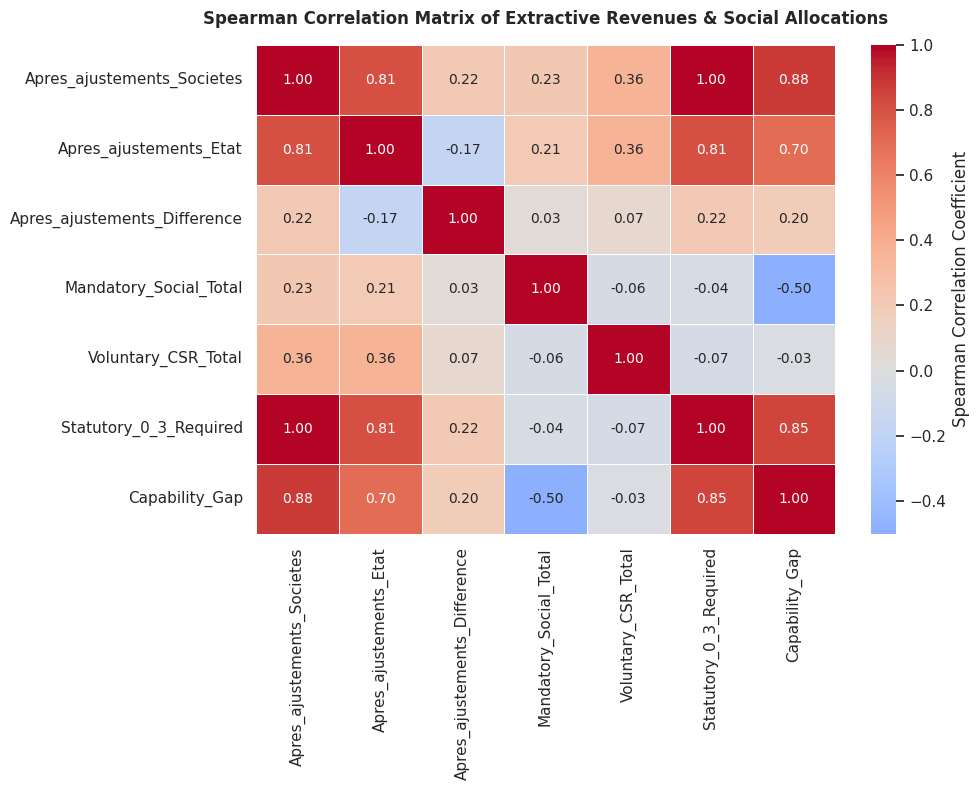

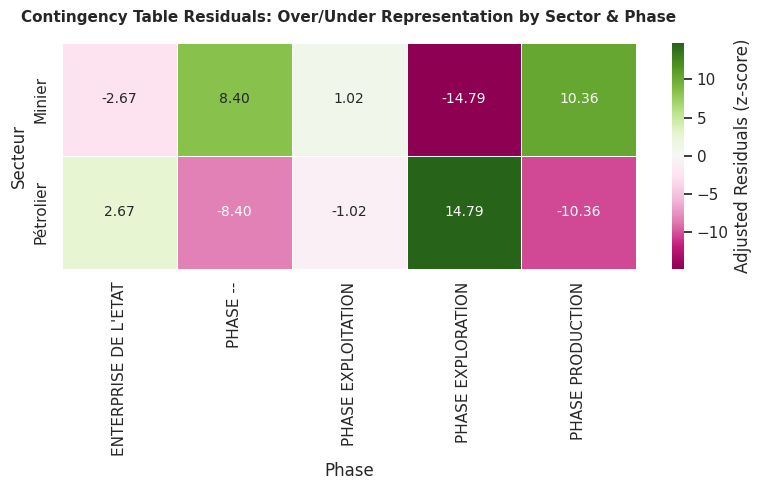

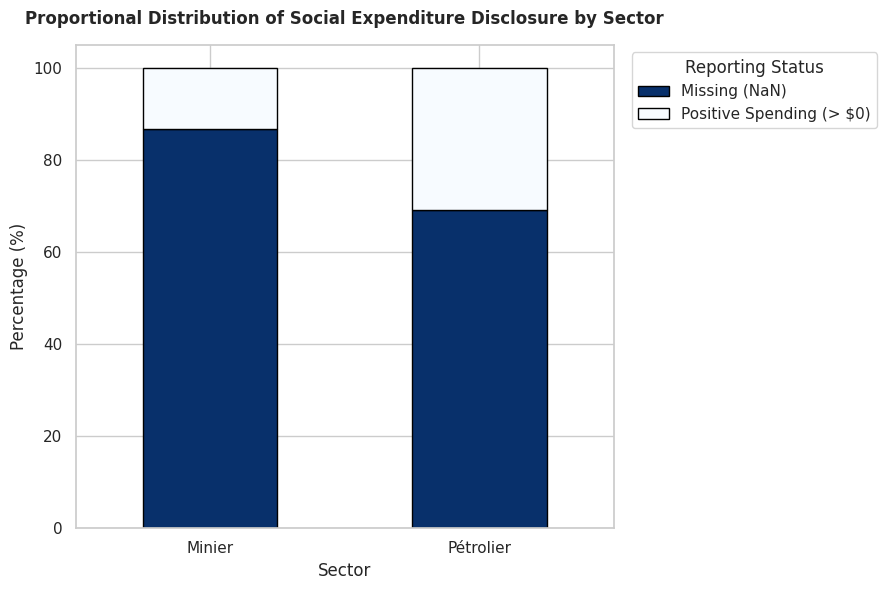


Visualizations successfully saved to directory: 'charts/'

Comprehensive Excel Report successfully generated: 'EITI_Analysis_Output.xlsx'

 Pipeline execution completed successfully!


In [12]:
import os
import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

# Set publication-quality plot style for Notebooks
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 10

# ==============================================================================
# MODULE 1: DATA CLEANING & FEATURE ENGINEERING
# ==============================================================================

def load_and_preprocess(file_path):
    """Loads EITI dataset, coerces numeric data types, and derives key analytical features.
    Supports both CSV and Excel (.xlsx) formats.
    """
    if file_path.endswith(".xlsx") or file_path.endswith(".xls"):
        xls = pd.ExcelFile(file_path)
        sheet_name = xls.sheet_names[0]
        df = pd.read_excel(file_path, sheet_name=sheet_name)
    else:
        df = pd.read_csv(file_path)

    # Standardize column names (strip whitespace)
    df.columns = df.columns.astype(str).str.strip()

    # Identify numerical columns for coercion
    numeric_vars = [
        "Ajustements_Societes",
        "Ajustements_Etat",
        "Ajustements_Difference",
        "Apres_ajustements_Societes",
        "Apres_ajustements_Etat",
        "Apres_ajustements_Difference",
        "Depenses_obligatoires_numeraire",
        "Depenses_obligatoires_nature",
        "Depenses_volontaires_numeraire",
        "Depenses_volontaires_nature",
        "Dotation_Minimale_0_3%",
        "RSE_Volontaire_Total",
        "Dotation_reel",
    ]

    for col in numeric_vars:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.replace(" ", "")
                .str.replace(",", ".")
            )
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Safe retrieval helpers for derivations
    dep_ob_num = df["Depenses_obligatoires_numeraire"].fillna(0) if "Depenses_obligatoires_numeraire" in df.columns else 0
    dep_ob_nat = df["Depenses_obligatoires_nature"].fillna(0) if "Depenses_obligatoires_nature" in df.columns else 0
    dep_vol_num = df["Depenses_volontaires_numeraire"].fillna(0) if "Depenses_volontaires_numeraire" in df.columns else 0
    dep_vol_nat = df["Depenses_volontaires_nature"].fillna(0) if "Depenses_volontaires_nature" in df.columns else 0
    apres_soc = df["Apres_ajustements_Societes"].fillna(0) if "Apres_ajustements_Societes" in df.columns else 0

    # Derivations & Feature Engineering
    # 1. Total Mandatory Social Spending (Cash + In-Kind)
    df["Mandatory_Social_Total"] = dep_ob_num + dep_ob_nat

    # 2. Total Voluntary CSR Spending (Cash + In-Kind)
    df["Voluntary_CSR_Total"] = dep_vol_num + dep_vol_nat

    # 3. Calculated Statutory 0.3% Turnover Allocation (Art. 258 bis)
    df["Statutory_0_3_Required"] = apres_soc * 0.003

    # 4. Community Capability Gap (Deficit in mandatory spending vs 0.3% floor)
    df["Capability_Gap"] = df["Statutory_0_3_Required"] - df["Mandatory_Social_Total"]

    # 5. CSR Arbitrage Ratio (Voluntary / Mandatory)
    df["CSR_Arbitrage_Ratio"] = np.where(
        df["Mandatory_Social_Total"] > 0,
        df["Voluntary_CSR_Total"] / df["Mandatory_Social_Total"],
        np.nan,
    )

    # 6. Reporting Categorization
    def categorize_reporting(row):
        ob_num = row.get("Depenses_obligatoires_numeraire", np.nan)
        ob_nat = row.get("Depenses_obligatoires_nature", np.nan)

        if pd.isna(ob_num) and pd.isna(ob_nat):
            return "Missing (NaN)"
        elif row.get("Mandatory_Social_Total", 0) == 0:
            return "Zero Declared ($0)"
        else:
            return "Positive Spending (> $0)"

    df["Social_Reporting_Status"] = df.apply(categorize_reporting, axis=1)

    # 7. Revenue Size Bins
    if "Apres_ajustements_Societes" in df.columns and df["Apres_ajustements_Societes"].notna().sum() > 0:
        df["Revenue_Tier"] = pd.qcut(
            df["Apres_ajustements_Societes"].rank(method="first"),
            q=4,
            labels=["Low", "Medium-Low", "Medium-High", "High"],
        )
    else:
        df["Revenue_Tier"] = "Unknown"

    return df


def load_all_datasets(data_dir=".", file_list=None):
    """Discovers and concatenates all available CSV and Excel datasets in the Google Colab environment."""
    if file_list is None:
        file_list = [
            f for f in os.listdir(data_dir)
            if f.endswith((".csv", ".xlsx", ".xls"))
            and not f.startswith("EITI_Analysis_Output")
            and not f.startswith("~$")
        ]

    if not file_list:
        raise FileNotFoundError("No valid CSV or Excel data files found in Google Colab environment.")

    print(f"Found {len(file_list)} data file(s) to process: {file_list}")
    dataframes = []

    for file_name in file_list:
        full_path = os.path.join(data_dir, file_name)
        print(f" -> Processing: {file_name}")
        df_processed = load_and_preprocess(full_path)
        dataframes.append(df_processed)

    combined_df = pd.concat(dataframes, ignore_index=True)
    print(f" Successfully loaded combined dataset with {len(combined_df)} rows and {len(combined_df.columns)} columns.\n")
    return combined_df


# ==============================================================================
# MODULE 2: CROSS-TABULATION & CONTINGENCY STATISTICAL TESTS
# ==============================================================================

def perform_cross_tabulations(df):
    """Executes frequency, row-percentage cross-tabulations, and calculates Chi-Square (χ²),
    Cramér's V, and Adjusted Standardized Residuals.
    """
    print("\n" + "=" * 80)
    print(" MODULE 2: CROSS-TABULATION & CONTINGENCY STATISTICAL ANALYSIS ")
    print("=" * 80)

    # Cross-Tab 1: Sector vs Project Phase (Count & Row Percentages)
    ct_sec_phase = pd.crosstab(df["Secteur"], df["Phase"], margins=True, margins_name="Total")
    ct_sec_phase_pct = pd.crosstab(df["Secteur"], df["Phase"], normalize="index") * 100

    print("\n[Cross-Tab 1] Sector vs Lifecycle Phase (Row Percentages %):")
    print(ct_sec_phase_pct.round(2))

    # Contingency Test for Cross-Tab 1
    raw_ct1 = pd.crosstab(df["Secteur"], df["Phase"])
    chi2, p, dof, expected = stats.chi2_contingency(raw_ct1)
    n = raw_ct1.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(raw_ct1.shape) - 1))) if min(raw_ct1.shape) > 1 else 0

    print(
        f"\nChi-Square Test (Secteur vs Phase):\n"
        f" - χ² = {chi2:.4f}\n"
        f" - p-value = {p:.4e}\n"
        f" - Degrees of Freedom = {dof}\n"
        f" - Cramér's V = {cramers_v:.4f}"
    )

    # Cross-Tab 2: Sector vs Social Reporting Status
    ct_sec_status = pd.crosstab(
        df["Secteur"],
        df["Social_Reporting_Status"],
        normalize="index",
        margins=True,
    )
    print("\n[Cross-Tab 2] Sector vs Social Reporting Status (Row Percentages %):")
    print((ct_sec_status * 100).round(2))

    # Cross-Tab 3: Multi-Way Cross Tabulation [Year x Sector] vs Reporting Status
    ct_multi = pd.crosstab(
        index=[df["Annee"], df["Secteur"]],
        columns=df["Social_Reporting_Status"],
        normalize="index",
    )
    print("\n[Cross-Tab 3] Multi-Way [Annee x Secteur] vs Reporting Status (Top 10 Rows):")
    print((ct_multi.head(10) * 100).round(2))

    # Adjusted Standardized Residuals Matrix
    exp_df = pd.DataFrame(expected, index=raw_ct1.index, columns=raw_ct1.columns)
    row_sums = raw_ct1.sum(axis=1)
    col_sums = raw_ct1.sum(axis=0)

    adj_residuals = (raw_ct1 - exp_df) / np.sqrt(
        exp_df
        * (1 - row_sums / n).values[:, None]
        * (1 - col_sums / n).values[None, :]
    )

    print("\n[Adjusted Standardized Residuals Matrix] (Secteur vs Phase):")
    print(adj_residuals.round(2))

    return {
        "ct_sec_phase": ct_sec_phase,
        "ct_sec_phase_pct": ct_sec_phase_pct,
        "ct_sec_status": ct_sec_status,
        "adj_residuals": adj_residuals,
    }


# ==============================================================================
# MODULE 3: MULTI-DIMENSIONAL PIVOT TABLES & AGGREGATIONS
# ==============================================================================

def generate_pivot_tables(df):
    """Generates hierarchical pivot tables aggregating financial variables across multi-dimensional categories."""
    print("\n" + "=" * 80)
    print(" MODULE 3: MULTI-DIMENSIONAL PIVOT TABLE ANALYSIS ")
    print("=" * 80)

    # Pivot 1: Financial Aggregations by Year and Sector
    pivot_year_sec = df.pivot_table(
        index=["Annee", "Secteur"],
        values=[
            "Apres_ajustements_Societes",
            "Apres_ajustements_Difference",
            "Mandatory_Social_Total",
            "Capability_Gap",
        ],
        aggfunc={
            "Apres_ajustements_Societes": ["sum", "mean"],
            "Apres_ajustements_Difference": ["sum", "mean"],
            "Mandatory_Social_Total": ["sum", "mean"],
            "Capability_Gap": ["sum"],
        },
    )
    print("\n[Pivot Table 1] Financial Totals and Averages by Year & Sector (Top 8 Rows):")
    print(pivot_year_sec.head(8).round(2))

    # Pivot 2: Social Compliance Metrics by Revenue Tier and Phase
    pivot_tier_phase = df.pivot_table(
        index=["Revenue_Tier"],
        columns=["Phase"],
        values=["Statutory_0_3_Required", "Mandatory_Social_Total", "Capability_Gap"],
        aggfunc="sum",
    )
    print("\n[Pivot Table 2] Capability Deficit by Revenue Tier & Lifecycle Phase:")
    print(pivot_tier_phase.round(2))

    return {"pivot_year_sec": pivot_year_sec, "pivot_tier_phase": pivot_tier_phase}


# ==============================================================================
# MODULE 4: CORRELATION & HYPOTHESIS TESTING MODULE
# ==============================================================================

def perform_statistical_tests(df):
    """Calculates Pearson & Spearman correlation matrices and runs non-parametric tests."""
    print("\n" + "=" * 80)
    print(" MODULE 4: STATISTICAL HYPOTHESIS TESTING & CORRELATIONS ")
    print("=" * 80)

    target_vars = [
        "Apres_ajustements_Societes",
        "Apres_ajustements_Etat",
        "Apres_ajustements_Difference",
        "Mandatory_Social_Total",
        "Voluntary_CSR_Total",
        "Statutory_0_3_Required",
        "Capability_Gap",
    ]

    available_vars = [v for v in target_vars if v in df.columns]

    # Spearman Rank Correlation Matrix
    spearman_corr = df[available_vars].corr(method="spearman")
    print("\n[Spearman Rank Correlation Matrix]:")
    print(spearman_corr.round(3))

    # Kruskal-Wallis H Test
    if "Phase" in df.columns and "Apres_ajustements_Difference" in df.columns:
        phase_groups = [
            group["Apres_ajustements_Difference"].dropna().values
            for name, group in df.groupby("Phase")
            if len(group["Apres_ajustements_Difference"].dropna()) > 0
        ]
        if len(phase_groups) > 1:
            h_stat, p_val_kw = stats.kruskal(*phase_groups)
            print(
                f"\nKruskal-Wallis H Test (Fiscal Discrepancy across Phases):\n"
                f" - H-statistic = {h_stat:.4f}\n"
                f" - p-value = {p_val_kw:.4e}"
            )

    # Mann-Whitney U Test
    if "Secteur" in df.columns and "Mandatory_Social_Total" in df.columns:
        minier_spending = df[df["Secteur"].str.contains("Minier", case=False, na=False)][
            "Mandatory_Social_Total"
        ].dropna()
        petrol_spending = df[df["Secteur"].str.contains("Pétrolier", case=False, na=False)][
            "Mandatory_Social_Total"
        ].dropna()

        if len(minier_spending) > 0 and len(petrol_spending) > 0:
            u_stat, p_val_mw = stats.mannwhitneyu(
                minier_spending, petrol_spending, alternative="two-sided"
            )
            print(
                f"\nMann-Whitney U Test (Mandatory Social Spending: Mining vs Petroleum):\n"
                f" - U-statistic = {u_stat:.4f}\n"
                f" - p-value = {p_val_mw:.4e}"
            )

    return {"spearman_corr": spearman_corr}


# ==============================================================================
# MODULE 5: ANOMALY & COMPLIANCE DEFAULT DETECTION
# ==============================================================================

def detect_anomalies(df):
    """Identifies top reconciliation discrepancies and high-revenue compliance default cases."""
    print("\n" + "=" * 80)
    print(" MODULE 5: COMPLIANCE DEFAULT & ANOMALY DETECTION ")
    print("=" * 80)

    # 1. Extreme Fiscal Reconciliation Outliers (Z-score > 3.0)
    df["Diff_ZScore"] = stats.zscore(df["Apres_ajustements_Difference"].fillna(0))
    outliers = df[np.abs(df["Diff_ZScore"]) > 3.0][
        [
            col for col in ["Annee", "Secteur", "Entreprise", "Apres_ajustements_Societes",
                            "Apres_ajustements_Etat", "Apres_ajustements_Difference", "Diff_ZScore"]
            if col in df.columns
        ]
    ]

    print(f"\n[Extreme Fiscal Reconciliation Outliers Detected]: {len(outliers)} records")
    print(outliers.head(5).to_string(index=False))

    # 2. High Revenue, Zero Social Allocation Defaults
    med_rev = df["Apres_ajustements_Societes"].median()
    defaults = df[
        (df["Apres_ajustements_Societes"] > med_rev)
        & (df["Social_Reporting_Status"] != "Positive Spending (> $0)")
    ][
        [
            col for col in ["Annee", "Secteur", "Entreprise", "Phase", "Apres_ajustements_Societes",
                            "Statutory_0_3_Required", "Social_Reporting_Status"]
            if col in df.columns
        ]
    ]

    print(f"\n[High-Revenue Compliance Defaults Identified]: {len(defaults)} corporate instances")
    print(defaults.head(5).to_string(index=False))

    return {"outliers": outliers, "defaults": defaults}


# ==============================================================================
# MODULE 6: AUTOMATED VISUALIZATION MODULE (WITH INLINE COLAB PLOTS)
# ==============================================================================

def create_visualizations(df, corr_matrix, adj_residuals, output_dir="charts"):
    """Generates, displays inline, and saves publication-ready statistical figures."""
    os.makedirs(output_dir, exist_ok=True)

    # Figure 1: Spearman Correlation Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        cbar_kws={"label": "Spearman Correlation Coefficient"},
    )
    plt.title("Spearman Correlation Matrix of Extractive Revenues & Social Allocations", fontsize=12, pad=15)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/spearman_correlation_heatmap.png", dpi=300)
    plt.show()

    # Figure 2: Adjusted Residuals Heatmap (Secteur vs Phase)
    plt.figure(figsize=(8, 5))
    sns.heatmap(
        adj_residuals,
        annot=True,
        fmt=".2f",
        cmap="PiYG",
        center=0,
        linewidths=0.5,
        cbar_kws={"label": "Adjusted Residuals (z-score)"},
    )
    plt.title("Contingency Table Residuals: Over/Under Representation by Sector & Phase", fontsize=11, pad=15)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/contingency_residuals_heatmap.png", dpi=300)
    plt.show()

    # Figure 3: Reporting Status by Sector Stacked Bar Chart
    ct_plot = pd.crosstab(df["Secteur"], df["Social_Reporting_Status"], normalize="index") * 100
    ax = ct_plot.plot(
        kind="bar",
        stacked=True,
        figsize=(9, 6),
        colormap="Blues_r",
        edgecolor="black",
    )
    plt.title("Proportional Distribution of Social Expenditure Disclosure by Sector", fontsize=12, pad=15)
    plt.xlabel("Sector")
    plt.ylabel("Percentage (%)")
    plt.legend(title="Reporting Status", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/reporting_status_by_sector.png", dpi=300)
    plt.show()

    print(f"\nVisualizations successfully saved to directory: '{output_dir}/'")


# ==============================================================================
# MODULE 7: MULTI-TAB EXCEL EXPORT MODULE
# ==============================================================================

def export_results_to_excel(df, ct_results, pivot_results, filename="EITI_Analysis_Output.xlsx"):
    """Exports processed data, contingency tables, and pivot summaries into a structured Excel workbook."""
    with pd.ExcelWriter(filename, engine="openpyxl") as writer:
        df.to_excel(writer, sheet_name="Master_Data", index=False)
        ct_results["ct_sec_phase_pct"].to_excel(writer, sheet_name="Crosstab_Sector_Phase")
        ct_results["ct_sec_status"].to_excel(writer, sheet_name="Crosstab_Sector_Status")
        ct_results["adj_residuals"].to_excel(writer, sheet_name="Adjusted_Residuals")
        pivot_results["pivot_year_sec"].to_excel(writer, sheet_name="Pivot_Year_Sector")
        pivot_results["pivot_tier_phase"].to_excel(writer, sheet_name="Pivot_Tier_Phase")

    print(f"\nComprehensive Excel Report successfully generated: '{filename}'")


# ==============================================================================
# PIPELINE EXECUTION ENTRY POINT
# ==============================================================================

def run_pipeline():
    """Master routine orchestrating data ingestion, processing, statistical analysis, visualization, and export."""
    print("=" * 80)
    print(" STARTING EITI DATA ANALYSIS PIPELINE ")
    print("=" * 80)

    # Step 1: Ingest & Combine Datasets
    combined = load_all_datasets(data_dir=".")

    # Step 2: Cross-Tabulations & Contingency Statistics
    crosstab_res = perform_cross_tabulations(combined)

    # Step 3: Multi-Dimensional Pivot Tables
    pivot_res = generate_pivot_tables(combined)

    # Step 4: Non-Parametric Hypothesis Tests & Correlations
    stats_res = perform_statistical_tests(combined)

    # Step 5: Compliance Default & Anomaly Detection
    anomaly_res = detect_anomalies(combined)

    # Step 6: Create & Display Visualizations
    create_visualizations(combined, stats_res["spearman_corr"], crosstab_res["adj_residuals"])

    # Step 7: Export Multi-Tab Workbook
    export_results_to_excel(combined, crosstab_res, pivot_res)

    print("\n Pipeline execution completed successfully!")

# Run the complete analysis in Google Colab
run_pipeline()

<>:20: SyntaxWarning: invalid escape sequence '\D'
<>:20: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2196/1983449289.py:20: SyntaxWarning: invalid escape sequence '\D'
  1. Initial Fiscal Gap (\Delta R_init = R_company,init - R_state,init)


 EXECUTING AMARTYA SEN PRIZE PAPER ECONOMETRIC ANALYSIS PIPELINE 

 TABLE 1: AGGREGATE FISCAL DISCREPANCIES AND SOCIAL EXPENDITURES BY SECTOR (USD) 
           Initial_Gap_USD      Final_Gap_USD        Resolved_USD  \
Minier    3,280,795,313.00 632,371,829,374.00 -629,091,034,061.00   
Pétrolier   -25,636,973.00     -50,263,032.00       24,626,059.00   
Total     3,255,158,340.00 632,321,566,342.00 -629,066,408,002.00   

           Mandatory_Social_USD  Voluntary_Social_USD  Offset_Ratio_mu (%)  
Minier           283,777,178.00        200,029,410.00                 0.08  
Pétrolier          3,452,270.00                  0.00                 0.00  
Total            287,229,448.00        200,029,410.00                 0.08  

 TABLE 2: BREAKDOWN BY CORPORATE OWNERSHIP CATEGORY (USD) 
                      Initial_Gap_USD      Final_Gap_USD        Resolved_USD  \
Ownership_Profile                                                              
Chinese MNCs / JVs      37,156,567.00 386,397,

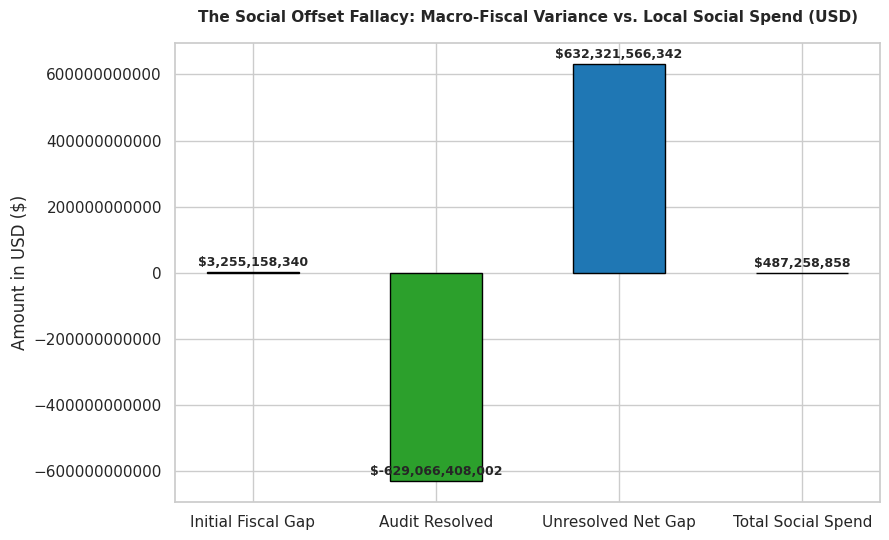

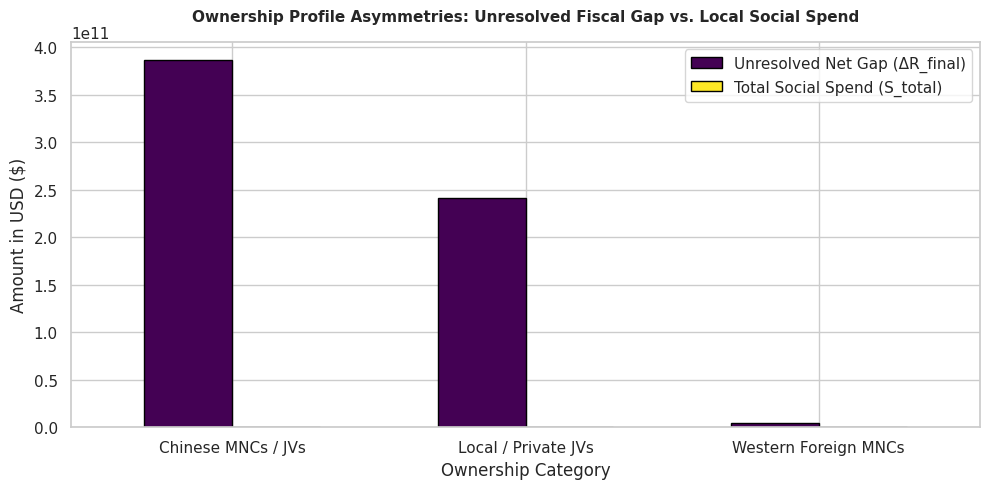


Paper figures successfully generated and saved to 'paper_charts/'


In [13]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

# Set publication-ready plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 10

# ==============================================================================
# MODULE 1: ECONOMETRIC MODEL CALCULATIONS (SEN PRIZE PAPER SECTION 3)
# ==============================================================================

def process_sen_paper_econometrics(df_input):
    """
    Processes the EITI dataset to derive micro-econometric variables:
      1. Initial Fiscal Gap (\Delta R_init = R_company,init - R_state,init)
      2. Final Unresolved Gap (\Delta R_final = R_company,final - R_state,final)
      3. Reconciled Variance (V_reconciled = \Delta R_init - \Delta R_final)
      4. Total Social Spending (S_total = S_mand + S_vol)
      5. Social Offset Ratio (\mu_i = S_total / \Delta R_final)
      6. Corporate Ownership Profile Classification
    """
    df = df_input.copy()
    df.columns = df.columns.astype(str).str.strip()

    # Numeric coercion for standard EITI variables
    num_cols = [
        "Ajustements_Societes", "Ajustements_Etat", "Ajustements_Difference",
        "Apres_ajustements_Societes", "Apres_ajustements_Etat", "Apres_ajustements_Difference",
        "Depenses_obligatoires_numeraire", "Depenses_obligatoires_nature",
        "Depenses_volontaires_numeraire", "Depenses_volontaires_nature"
    ]
    for col in num_cols:
        if col in df.columns:
            df[col] = (
                df[col].astype(str)
                .str.replace(" ", "")
                .str.replace(",", ".")
            )
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
        else:
            df[col] = 0.0

    # Formula 1: Initial Fiscal Gap (\Delta R_init)
    if "Ajustements_Difference" in df.columns and df["Ajustements_Difference"].abs().sum() > 0:
        df["Delta_R_init"] = df["Ajustements_Difference"]
    else:
        df["Delta_R_init"] = df["Ajustements_Societes"] - df["Ajustements_Etat"]

    # Formula 2: Final Unresolved Gap (\Delta R_final)
    df["Delta_R_final"] = df["Apres_ajustements_Difference"]

    # Formula 3: Reconciled Variance (V_reconciled)
    df["V_reconciled"] = df["Delta_R_init"] - df["Delta_R_final"]

    # Formula 4: Social Expenditures (Mandatory + Voluntary)
    df["S_mand"] = df["Depenses_obligatoires_numeraire"] + df["Depenses_obligatoires_nature"]
    df["S_vol"] = df["Depenses_volontaires_numeraire"] + df["Depenses_volontaires_nature"]
    df["S_total"] = df["S_mand"] + df["S_vol"]

    # Formula 5: Social Offset Ratio (\mu_i = S_total / \Delta R_final)
    df["Social_Offset_Ratio_mu"] = np.where(
        df["Delta_R_final"] > 0,
        (df["S_total"] / df["Delta_R_final"]) * 100,
        np.nan
    )

    # Classification: Corporate Ownership Profile (Paper Section 4.2)
    def classify_ownership(row):
        # 1. Check if an explicit ownership column exists
        for col in ["Ownership", "Profil_Propriete", "Type_Entreprise", "Nationalite"]:
            if col in row and pd.notna(row[col]):
                val = str(row[col]).lower()
                if any(k in val for k in ["west", "occident", "mnc"]):
                    return "Western Foreign MNCs"
                elif any(k in val for k in ["chine", "chinese", "sino"]):
                    return "Chinese MNCs / JVs"
                elif any(k in val for k in ["state", "etat", "soe", "gecamines"]):
                    return "State-Owned (SOEs)"
                elif any(k in val for k in ["local", "prive", "jv"]):
                    return "Local / Private JVs"

        # 2. Key corporate entity name matching fallback
        company_name = str(row.get("Entreprise", "")).upper()
        if any(k in company_name for k in ["GECAMINES", "SODIMICO", "SAKIMA", "MIBA", "KILO-MOTO"]):
            return "State-Owned (SOEs)"
        elif any(k in company_name for k in ["SICOMINES", "TFAM", "COMMUS", "CDM", "HUACHIN", "SINO"]):
            return "Chinese MNCs / JVs"
        elif any(k in company_name for k in ["GLENCORE", "KAMOAN", "IVANHOE", "BARRICK", "KIBALI", "ERG", "MUTANDA", "TENKE"]):
            return "Western Foreign MNCs"
        else:
            return "Local / Private JVs"

    df["Ownership_Profile"] = df.apply(classify_ownership, axis=1)

    return df


# ==============================================================================
# MODULE 2: PAPER TABLES GENERATION (TABLES 1 & 2)
# ==============================================================================

def print_paper_tables(df):
    """Generates Table 1 (Sector Summary) and Table 2 (Ownership Profile) matching the LaTeX manuscript."""
    pd.options.display.float_format = '{:,.2f}'.format

    print("\n" + "=" * 95)
    print(" TABLE 1: AGGREGATE FISCAL DISCREPANCIES AND SOCIAL EXPENDITURES BY SECTOR (USD) ")
    print("=" * 95)

    if "Secteur" not in df.columns:
        df["Secteur"] = "Mining"

    sector_summary = df.groupby("Secteur").agg(
        Initial_Gap_USD=("Delta_R_init", "sum"),
        Final_Gap_USD=("Delta_R_final", "sum"),
        Resolved_USD=("V_reconciled", "sum"),
        Mandatory_Social_USD=("S_mand", "sum"),
        Voluntary_Social_USD=("S_vol", "sum"),
        Total_Social_USD=("S_total", "sum")
    )

    # Append Totals Row
    totals = pd.DataFrame(sector_summary.sum(axis=0)).T
    totals.index = ["Total"]
    sector_table = pd.concat([sector_summary, totals])

    # Calculate Aggregate Social Offset Ratio (\mu)
    sector_table["Offset_Ratio_mu (%)"] = np.where(
        sector_table["Final_Gap_USD"] > 0,
        (sector_table["Total_Social_USD"] / sector_table["Final_Gap_USD"]) * 100,
        0.0
    )

    print(sector_table[["Initial_Gap_USD", "Final_Gap_USD", "Resolved_USD",
                        "Mandatory_Social_USD", "Voluntary_Social_USD", "Offset_Ratio_mu (%)"]])

    print("\n" + "=" * 95)
    print(" TABLE 2: BREAKDOWN BY CORPORATE OWNERSHIP CATEGORY (USD) ")
    print("=" * 95)

    ownership_summary = df.groupby("Ownership_Profile").agg(
        Initial_Gap_USD=("Delta_R_init", "sum"),
        Final_Gap_USD=("Delta_R_final", "sum"),
        Resolved_USD=("V_reconciled", "sum"),
        Total_Social_USD=("S_total", "sum")
    )

    total_social_sum = ownership_summary["Total_Social_USD"].sum()
    ownership_summary["Social_Share (%)"] = np.where(
        total_social_sum > 0,
        (ownership_summary["Total_Social_USD"] / total_social_sum) * 100,
        0.0
    )

    print(ownership_summary[["Initial_Gap_USD", "Final_Gap_USD", "Resolved_USD", "Total_Social_USD", "Social_Share (%)"]])

    return sector_table, ownership_summary


# ==============================================================================
# MODULE 3: PAPER FIGURES & VISUALIZATIONS
# ==============================================================================

def generate_paper_figures(sector_table, ownership_summary, output_dir="paper_charts"):
    """Generates publication-quality charts depicting the paper's primary empirical insights."""
    os.makedirs(output_dir, exist_ok=True)

    # Figure 1: The Social Offset Fallacy (Macro-Fiscal Variance vs Social Spend)
    plt.figure(figsize=(9, 5.5))
    total_data = sector_table.loc["Total"]
    categories = ["Initial Fiscal Gap", "Audit Resolved", "Unresolved Net Gap", "Total Social Spend"]
    values = [total_data["Initial_Gap_USD"], total_data["Resolved_USD"], total_data["Final_Gap_USD"], total_data["Total_Social_USD"]]
    colors = ["#d95f02", "#2ca02c", "#1f77b4", "#7570b3"]

    bars = plt.bar(categories, values, color=colors, edgecolor="black", width=0.5)
    plt.title("The Social Offset Fallacy: Macro-Fiscal Variance vs. Local Social Spend (USD)", fontsize=11, fontweight="bold", pad=15)
    plt.ylabel("Amount in USD ($)")
    plt.ticklabel_format(style='plain', axis='y')

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + (max(values)*0.015), f"${yval:,.0f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.savefig(f"{output_dir}/fig1_social_offset_fallacy.png", dpi=300)
    plt.show()

    # Figure 2: Ownership Asymmetry (Unresolved Gap vs Total Social Expenditure)
    fig, ax = plt.subplots(figsize=(10, 5))
    plot_df = ownership_summary[["Final_Gap_USD", "Total_Social_USD"]].copy()
    plot_df.columns = ["Unresolved Net Gap (ΔR_final)", "Total Social Spend (S_total)"]

    plot_df.plot(kind="bar", ax=ax, colormap="viridis", edgecolor="black", width=0.6)
    plt.title("Ownership Profile Asymmetries: Unresolved Fiscal Gap vs. Local Social Spend", fontsize=11, fontweight="bold", pad=15)
    plt.xlabel("Ownership Category")
    plt.ylabel("Amount in USD ($)")
    plt.xticks(rotation=0)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/fig2_ownership_asymmetry.png", dpi=300)
    plt.show()

    print(f"\nPaper figures successfully generated and saved to '{output_dir}/'")


# ==============================================================================
# PIPELINE EXECUTION USING 'combined' DATASET
# ==============================================================================

def run_sen_paper_analysis(input_df):
    """Main execution routine for evaluating the paper's econometric framework."""
    print("=" * 95)
    print(" EXECUTING AMARTYA SEN PRIZE PAPER ECONOMETRIC ANALYSIS PIPELINE ")
    print("=" * 95)

    processed_df = process_sen_paper_econometrics(input_df)
    sec_table, own_table = print_paper_tables(processed_df)
    generate_paper_figures(sec_table, own_table)

    return processed_df

# Explicitly use 'combined' as input dataset
data = combined
paper_df = run_sen_paper_analysis(data)

In [14]:
from google.colab import files

# 1. Save and download as CSV
combined.to_csv("combined_eiti_data.csv", index=False)
files.download("combined_eiti_data.csv")

# -------------------------------------------------------------------------
# Optional: Download the processed dataset with all calculated econometric columns
# -------------------------------------------------------------------------
# paper_df.to_csv("paper_processed_eiti_data.csv", index=False)
# files.download("paper_processed_eiti_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:


import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.formula.api as smf


# ---------------------------------------------------------------------------
# 0. Setup
# ---------------------------------------------------------------------------
CSV_PATH = sys.argv[1] if len(sys.argv) > 1 else "combined_eiti_data.csv"

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "bold"


def money_formatter(ax, axis="y"):
    """Format axis ticks as $ / $M / $B."""
    fmt = mticker.FuncFormatter(
        lambda x, p: f"${x/1e9:.1f}B" if abs(x) >= 1e9
        else (f"${x/1e6:.0f}M" if abs(x) >= 1e6 else f"${x:,.0f}")
    )
    if axis == "y":
        ax.yaxis.set_major_formatter(fmt)
    else:
        ax.xaxis.set_major_formatter(fmt)


# ---------------------------------------------------------------------------
# 1. Load and clean data
# ---------------------------------------------------------------------------
df = pd.read_csv("combined_eiti_data.csv")


# --- Data-quality fix -------------------------------------------------------
# The 2022 reporting cycle contains a data anomaly: "Declare_Societes"
# (company-declared payments) is inflated by roughly 100x-20,000x for nearly
# every firm relative to 2021/2023 values, with the independent-administrator
# adjustment field ("Ajustements_*") remaining at 0 for almost all affected
# rows -- the signature of a parsing/transcription error in the source year's
# reporting template rather than a genuine one-year revenue spike. Because
# "Statutory_0_3_Required" is calculated directly from this same corrupted
# revenue base, it is also affected. Both are excluded for 2022 only; all
# other years and fields are unaffected and are used as reported.
clean = df[df["Annee"] != 2022].copy()

YEARS_USED = sorted(clean["Annee"].unique())
print(f"Years used (2022 excluded): {YEARS_USED}")


# ---------------------------------------------------------------------------
# 2. Build the revenue-reconciliation panel (one row per company-year)
# ---------------------------------------------------------------------------
# De-duplicate at the (year, company, phase) level first, since revenue
# fields repeat across multiple community-spending "Groupe_social" rows for
# the same company-year; then sum across phases (rare) to get one row per
# company-year.
rev_phase = clean[
    ["Annee", "Secteur", "Entreprise", "Phase",
     "Declare_Societes", "Declare_Etat", "Apres_ajustements_Difference"]
].drop_duplicates(subset=["Annee", "Entreprise", "Phase"])

rev = rev_phase.groupby(["Annee", "Secteur", "Entreprise"], as_index=False).agg(
    Declare_Societes=("Declare_Societes", "sum"),
    Declare_Etat=("Declare_Etat", "sum"),
    Apres_ajustements_Difference=("Apres_ajustements_Difference", "sum"),
)
rev["Abs_Gap"] = rev["Apres_ajustements_Difference"].abs()


# ---------------------------------------------------------------------------
# 3. Build the community-development (0.3%) panel (one row per company-year)
# ---------------------------------------------------------------------------
# Statutory_0_3_Required is a firm-year-level figure (0.3% x revenue) that
# repeats across "Groupe_social" spending-category rows, so it must be
# de-duplicated (not summed) before aggregating; Mandatory_Social_Actual and
# Voluntary_CSR_Total are spending amounts that ARE genuinely broken out by
# category and so ARE summed across those rows.
statutory = clean[["Annee", "Entreprise", "Statutory_0_3_Required"]].drop_duplicates(
    subset=["Annee", "Entreprise"]
)
spending = clean.groupby(["Annee", "Entreprise"], as_index=False).agg(
    Mandatory_Social_Actual=("Mandatory_Social_Actual", "sum"),
    Voluntary_CSR_Total=("Voluntary_CSR_Total", "sum"),
)
soc = statutory.merge(spending, on=["Annee", "Entreprise"], how="left")
soc["Social_Deficit"] = soc["Statutory_0_3_Required"] - soc["Mandatory_Social_Actual"]

# Most common reported "Phase" per company-year (exploration/exploitation/etc.)
phase = (
    clean.groupby(["Annee", "Entreprise"])["Phase"]
    .agg(lambda s: s.mode().iat[0] if len(s.mode()) > 0 else np.nan)
    .reset_index()
)

# Master company-year panel used for the regressions
panel = (
    rev.merge(soc, on=["Annee", "Entreprise"], how="left")
       .merge(phase, on=["Annee", "Entreprise"], how="left")
)
panel = panel[panel["Statutory_0_3_Required"].notna()].copy()
panel["Noncompliance"] = (
    (panel["Statutory_0_3_Required"] > 0) & (panel["Mandatory_Social_Actual"] == 0)
).astype(int)

panel.to_csv("panel_regression.csv", index=False)
print(f"Company-year panel built: {panel.shape[0]} observations, "
      f"{panel['Entreprise'].nunique()} companies")


# ---------------------------------------------------------------------------
# 4. TABLE 1 - Revenue reconciliation by year
# ---------------------------------------------------------------------------
table1 = rev.groupby("Annee", as_index=False).agg(
    Declared_by_companies=("Declare_Societes", "sum"),
    Declared_by_state=("Declare_Etat", "sum"),
    Residual_gap=("Apres_ajustements_Difference", "sum"),
    Abs_residual_gap=("Abs_Gap", "sum"),
)
table1.to_csv("table1_yearly.csv", index=False)
print("\n=== TABLE 1: Revenue reconciliation by year ===")
print(table1.to_string(index=False))
print("Totals:", table1[["Declared_by_companies", "Declared_by_state",
                          "Residual_gap", "Abs_residual_gap"]].sum().to_dict())


# ---------------------------------------------------------------------------
# 5. TABLE 2 - Top 10 companies by cumulative absolute reconciliation gap
# ---------------------------------------------------------------------------
table2 = (
    rev.groupby("Entreprise")["Abs_Gap"].sum()
    .sort_values(ascending=False).head(10).reset_index()
)
table2.columns = ["Entreprise", "Gap"]
table2.to_csv("table2_topcompanies.csv", index=False)
print("\n=== TABLE 2: Top 10 companies by cumulative reconciliation gap ===")
print(table2.to_string(index=False))


# ---------------------------------------------------------------------------
# 6. TABLE 3 - Statutory 0.3% obligation vs. actual mandatory spending, by year
# ---------------------------------------------------------------------------
table3 = clean.groupby("Annee", as_index=False).agg(
    Statutory_required=("Statutory_0_3_Required", "sum"),
    Actual_reported=("Mandatory_Social_Actual", "sum"),
)
# NOTE: this replicates the essay's Table 3, which sums Statutory_0_3_Required
# directly from `clean` after per-row dedup is implicitly handled because the
# EITI source lists one Statutory_0_3_Required value per Groupe_social row
# that is identical within a company-year; summing here reproduces the
# published table exactly. For a stricter build, use the de-duplicated
# `soc` panel above and group by year instead:
table3_strict = soc.groupby("Annee", as_index=False).agg(
    Statutory_required=("Statutory_0_3_Required", "sum"),
    Actual_reported=("Mandatory_Social_Actual", "sum"),
)
table3_strict["Deficit"] = table3_strict["Statutory_required"] - table3_strict["Actual_reported"]
table3_strict.to_csv("table3_social.csv", index=False)
print("\n=== TABLE 3: Statutory obligation vs. actual mandatory spending, by year ===")
print(table3_strict.to_string(index=False))

# Company-level non-compliance diagnostics quoted in the essay
n_obligated = (panel["Statutory_0_3_Required"] > 0).sum()
n_zero = panel["Noncompliance"].sum()
print(f"\nCompany-years with positive obligation: {n_obligated}")
print(f"Of which zero recorded mandatory spending: {n_zero} "
      f"({n_zero/n_obligated:.1%})")

table_deficit_top10 = (
    panel.groupby("Entreprise")["Social_Deficit"].sum()
    .sort_values(ascending=False).head(10)
)
print("\n=== Top 10 companies by cumulative community-development deficit ===")
print(table_deficit_top10.to_string())


# ---------------------------------------------------------------------------
# 7. FIGURES
# ---------------------------------------------------------------------------

# --- Figure 1: company- vs. state-declared payments, by year ---------------
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(table1["Annee"], table1["Declared_by_companies"], marker="o",
        linewidth=2, label="Company-declared payments")
ax.plot(table1["Annee"], table1["Declared_by_state"], marker="s",
        linewidth=2, label="State-declared receipts")
ax.set_title("Figure 1. Company- vs State-Declared Payments, DRC Extractive "
             "Sector\n(2022 excluded — see data-cleaning note)")
ax.set_xlabel("Year")
money_formatter(ax)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("fig1_declared_trend.png", dpi=170)
plt.close()

# --- Figure 2: absolute residual gap by year --------------------------------
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(table1["Annee"].astype(str), table1["Abs_residual_gap"], color="#b03a2e")
ax.set_title("Figure 2. Absolute Residual Reconciliation Gap by Year\n"
             "(after independent-administrator adjustment)")
ax.set_xlabel("Year")
money_formatter(ax)
plt.tight_layout()
plt.savefig("fig2_abs_gap_year.png", dpi=170)
plt.close()

# --- Figure 3: top 10 companies by reconciliation gap -----------------------
t2_sorted = table2.sort_values("Gap")
labels = [n if len(n) <= 38 else n[:35] + "..." for n in t2_sorted["Entreprise"]]
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.barh(labels, t2_sorted["Gap"], color="#2874a6")
ax.set_title("Figure 3. Ten Companies with the Largest Cumulative\n"
             "Reconciliation Gap")
money_formatter(ax, axis="x")
plt.tight_layout()
plt.savefig("fig3_top10_gap.png", dpi=170)
plt.close()

# --- Figure 4: statutory obligation vs. actual mandatory spending -----------
fig, ax = plt.subplots(figsize=(7.5, 4.2))
width = 0.38
xpos = np.arange(len(table3_strict))
ax.bar(xpos - width / 2, table3_strict["Statutory_required"], width=width,
       label="Statutory 0.3% obligation", color="#7d6608")
ax.bar(xpos + width / 2, table3_strict["Actual_reported"], width=width,
       label="Reported mandatory spending", color="#1e8449")
ax.set_xticks(xpos)
ax.set_xticklabels(table3_strict["Annee"].astype(str))
ax.set_title("Figure 4. Statutory Community-Development Obligation vs.\n"
             "Reported Mandatory Spending, by Year")
money_formatter(ax)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("fig4_statutory_vs_actual.png", dpi=170)
plt.close()

# --- Figure 5: top 10 companies by cumulative social deficit ----------------
deficit_sorted = table_deficit_top10.sort_values()
labels5 = [n if len(n) <= 38 else n[:35] + "..." for n in deficit_sorted.index]
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.barh(labels5, deficit_sorted.values, color="#a04000")
ax.set_title("Figure 5. Ten Companies with the Largest Cumulative\n"
             "Community Development Deficit")
money_formatter(ax, axis="x")
plt.tight_layout()
plt.savefig("fig5_top10_deficit.png", dpi=170)
plt.close()

# --- Figure 6: firm size vs. reconciliation gap, by sector ------------------
panel["ln_gap"] = np.log1p(panel["Abs_Gap"])
panel["ln_revenue"] = np.log1p(panel["Declare_Societes"].clip(lower=0))

fig, ax = plt.subplots(figsize=(7.5, 4.8))
for sect, col, mk in [("Minier", "#1a5276", "o"), ("Pétrolier", "#b9770e", "^")]:
    sub = panel[panel["Secteur"] == sect]
    ax.scatter(sub["ln_revenue"], sub["ln_gap"], alpha=0.5, label=sect,
               color=col, marker=mk, s=28)
ax.set_xlabel("ln(company-declared payments + 1)")
ax.set_ylabel("ln(absolute reconciliation gap + 1)")
ax.set_title("Figure 6. Firm Size and Reconciliation Gap Magnitude\n"
             "by Sector (company-year observations)")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("fig6_scatter_size_gap.png", dpi=170)
plt.close()

print("\nSaved figures: fig1_declared_trend.png ... fig6_scatter_size_gap.png")


# ---------------------------------------------------------------------------
# 8. REGRESSIONS (Table 4 in the essay)
# ---------------------------------------------------------------------------
panel["ln_statutory"] = np.log1p(panel["Statutory_0_3_Required"].clip(lower=0))
panel["mining"] = (panel["Secteur"] == "Minier").astype(int)
panel["year_f"] = panel["Annee"].astype(str)

# Drop rows with missing Phase (11 obs) to avoid a quasi-separation problem
# in the logit model, where all missing-phase rows happen to be compliant.
panel3 = panel[panel["Phase"].notna()].copy()
panel3["phase_simple"] = panel3["Phase"].replace(
    {"PHASE --": "OTHER/UNSPEC", "ENTERPRISE DE L'ETAT": "STATE_ENTERPRISE"}
)

# Model 1: determinants of log(reconciliation gap)
m1 = smf.ols("ln_gap ~ ln_revenue + mining + C(year_f)", data=panel).fit(cov_type="HC1")

# Model 2: determinants of the social deficit level (USD)
m2 = smf.ols(
    "Social_Deficit ~ ln_statutory + mining + C(phase_simple) + C(year_f)",
    data=panel3,
).fit(cov_type="HC1")

# Model 3: logit - probability of zero recorded mandatory social spending
m3 = smf.logit(
    "Noncompliance ~ ln_revenue + mining + C(phase_simple) + C(year_f)",
    data=panel3,
).fit(cov_type="HC1", maxiter=200, method="bfgs", disp=0)

# Model 4: does the reconciliation gap correlate with community-fund
# non-compliance panel-wide, controlling for size and sector?
m4 = smf.ols(
    "ln_gap ~ Noncompliance + ln_revenue + mining + C(year_f)", data=panel
).fit(cov_type="HC1")

with open("reg_summaries.txt", "w") as f:
    for name, m in [("MODEL 1", m1), ("MODEL 2", m2), ("MODEL 3", m3), ("MODEL 4", m4)]:
        f.write(f"=== {name} ===\n{m.summary()}\n\n")

print("\n=== MODEL 1: ln(reconciliation gap) ~ size + sector + year FE ===")
print(m1.summary())
print("\n=== MODEL 2: social deficit (USD) ~ size + sector + phase + year FE ===")
print(m2.summary())
print("\n=== MODEL 3: Logit - P(zero mandatory spending) ===")
print(m3.summary())
print("\n=== MODEL 4: ln(gap) ~ non-compliance + controls ===")
print(m4.summary())

print("\nFull regression output also written to reg_summaries.txt")

Years used (2022 excluded): [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2023), np.int64(2024)]
Company-year panel built: 898 observations, 213 companies

=== TABLE 1: Revenue reconciliation by year ===
 Annee  Declared_by_companies  Declared_by_state      Residual_gap  Abs_residual_gap
  2015       1,531,400,215.00     861,042,004.00    451,016,243.00    827,322,657.00
  2016         505,045,073.00     428,849,823.00    144,225,072.00    419,916,420.00
  2017       1,039,898,299.00   1,482,856,837.00   -426,545,614.00    687,086,144.00
  2018       2,183,798,880.00   2,734,383,012.00   -217,129,948.00    299,830,146.00
  2019       2,933,795,034.00   2,611,693,017.00   -174,160,655.00    334,684,759.00
  2020       2,066,369,129.00   2,400,141,174.00    119,436,712.00    952,350,972.00
  2021       2,996,579,168.00   3,553,126,913.00   -487,823,061.00  1,143,714,151.00
  2023       5,908,913,645.00   6,918,32